In [11]:
import shap
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

shap.initjs()

In [2]:
with open("../models/xgb_time_model.pkl", "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded")

✅ Model loaded


In [3]:
df = pd.read_feather("../data/cleaned_data.feather")

print(df.shape)

(20216100, 18)


In [4]:
target = "meter_reading_log"

X = df.drop(columns=[target, "building_id", "energy_per_sqft"])
y = df[target]

print(X.shape)

(20216100, 15)


In [5]:
X_sample = X.sample(2000, random_state=42)

print(X_sample.shape)

(2000, 15)


In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed")

SHAP values computed


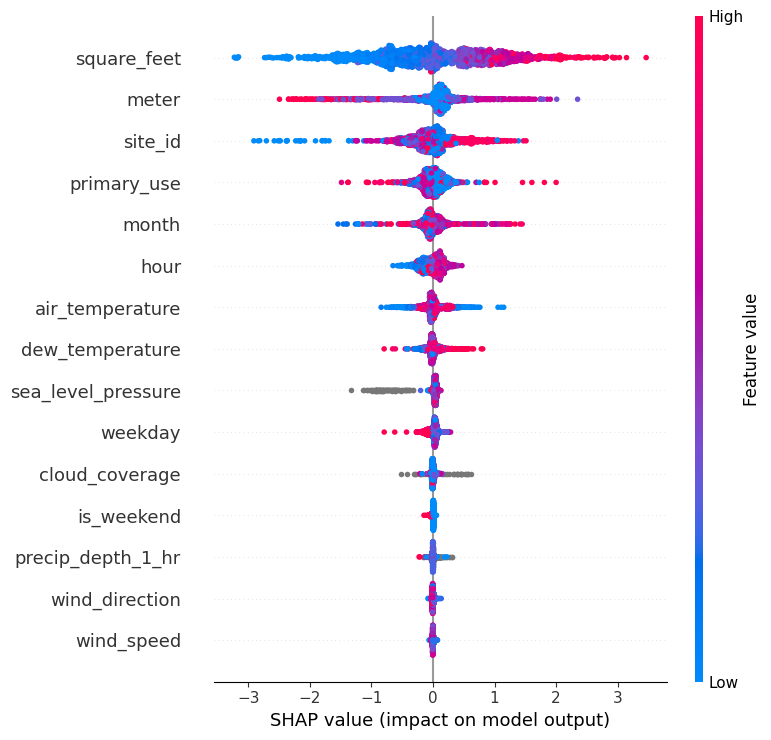

In [7]:
shap.summary_plot(shap_values, X_sample)

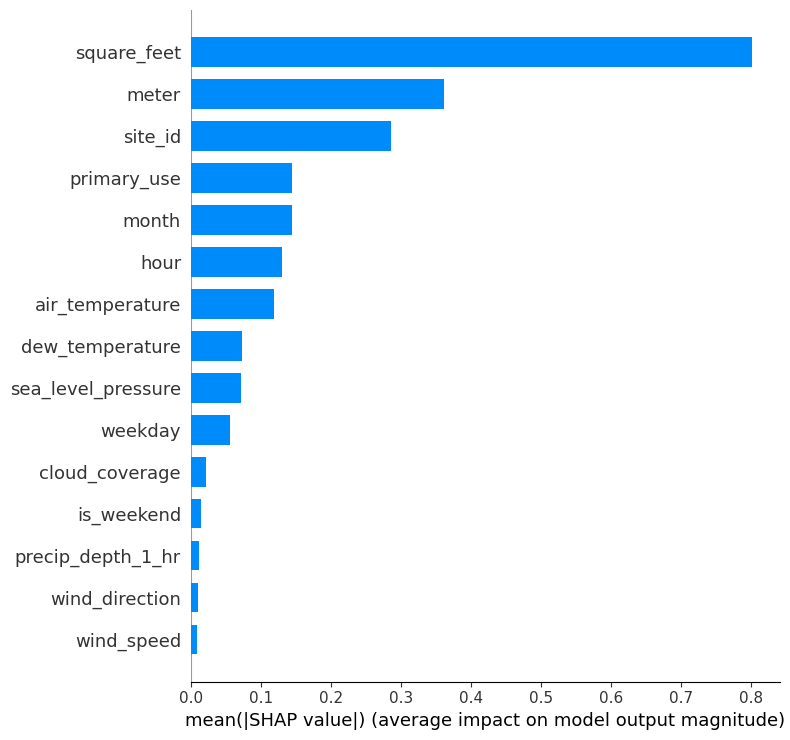

In [8]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

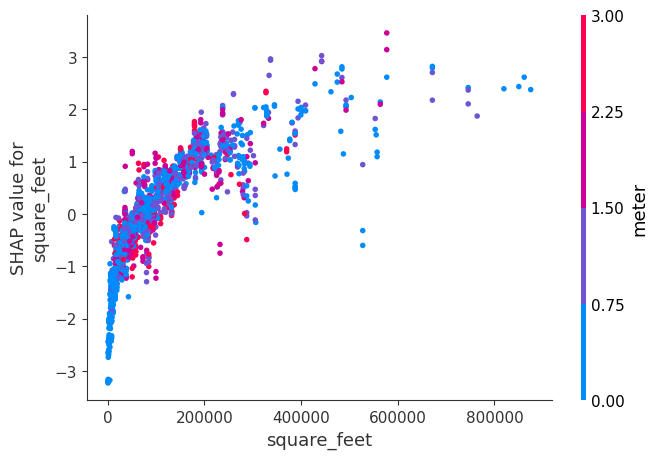

In [9]:
shap.dependence_plot("square_feet", shap_values, X_sample)

In [12]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0]
)

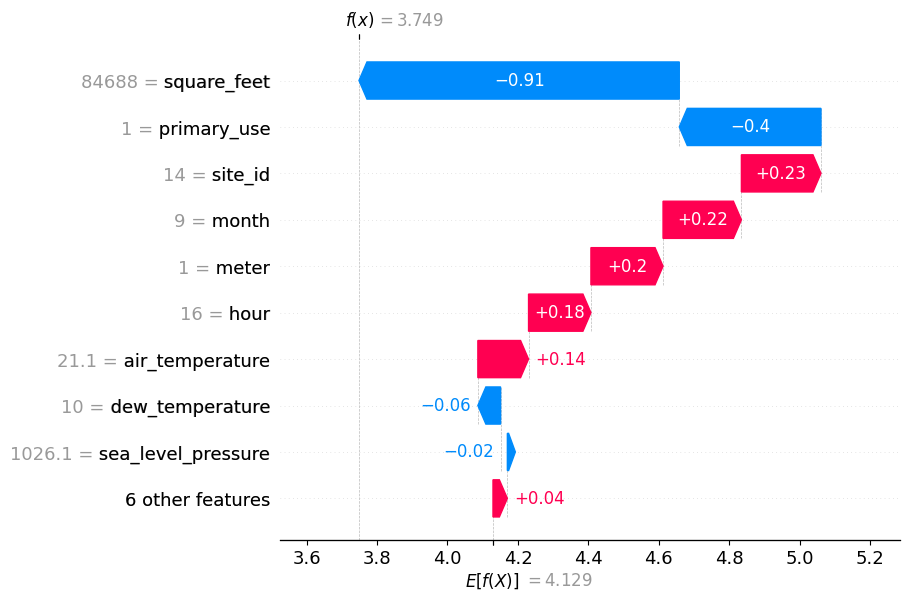

In [13]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns
    )
)

In [17]:
new_building = pd.DataFrame({
    "meter":[1],
    "site_id":[5],
    "primary_use":[2],
    "square_feet":[120000],
    "air_temperature":[30],
    "cloud_coverage":[4],
    "dew_temperature":[22],
    "precip_depth_1_hr":[0],
    "sea_level_pressure":[1015],
    "wind_direction":[200],
    "wind_speed":[3],
    "hour":[14],
    "month":[7],
    "weekday":[3],
    "is_weekend":[0]
})

In [18]:
pred = model.predict(new_building)
print(pred)

[6.1793885]


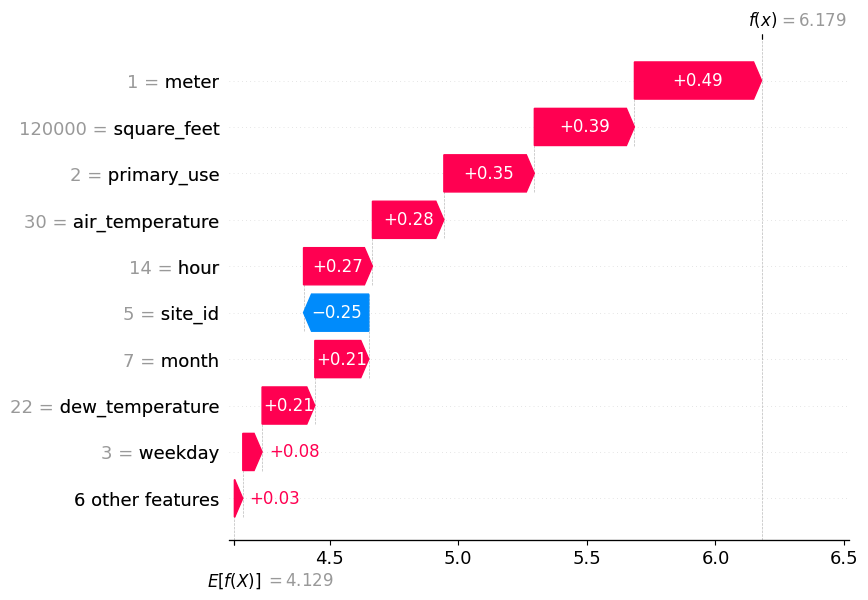

In [19]:
shap_val = explainer.shap_values(new_building)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_val[0],
        base_values=explainer.expected_value,
        data=new_building.iloc[0],
        feature_names=new_building.columns
    )
)

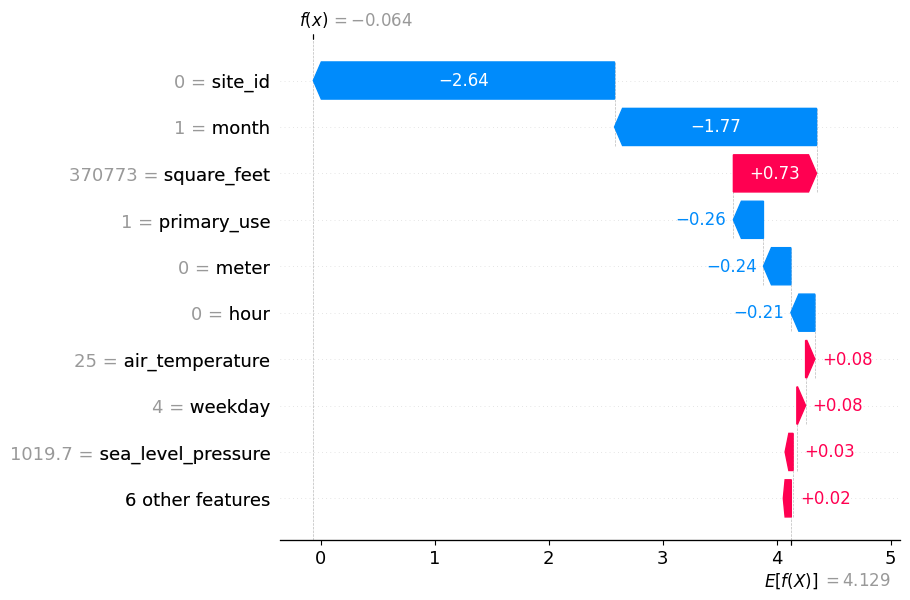

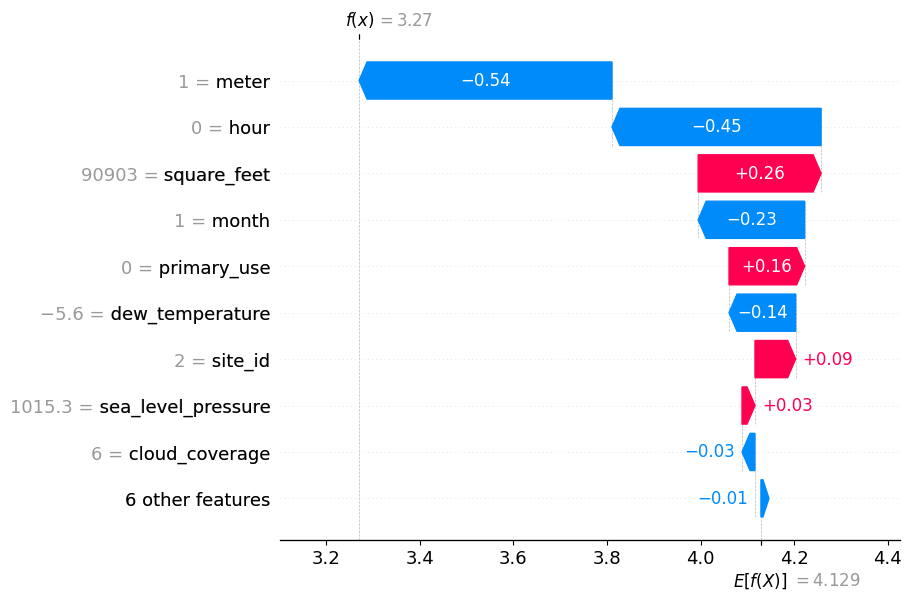

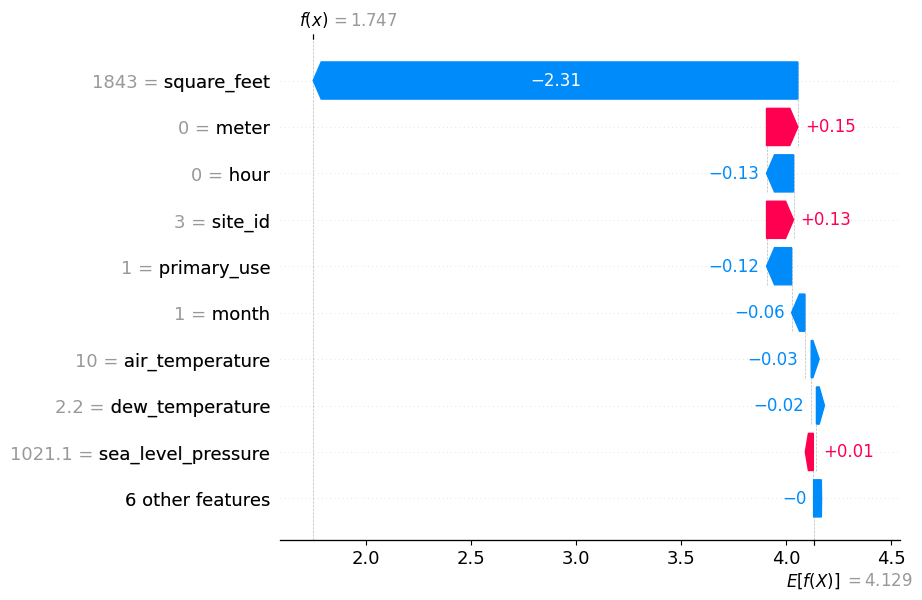

In [20]:
for i in [10, 200, 500]:
    sample = X.iloc[[i]]
    
    shap_val = explainer.shap_values(sample)
    
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_val[0],
            base_values=explainer.expected_value,
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )

In [21]:
shap_val = explainer.shap_values(new_building)

In [22]:
def explain_prediction(model, explainer, X_input):

    shap_values = explainer.shap_values(X_input)[0]

    prediction = model.predict(X_input)[0]

    base = explainer.expected_value

    features = X_input.columns
    values = X_input.iloc[0]

    explanation = []

    explanation.append(f"The predicted log energy consumption is {prediction:.3f}.")

    explanation.append(f"The average baseline prediction of the model is {base:.3f}.")

    explanation.append("The prediction changed due to the following factors:")

    for f, val, shap_val in zip(features, values, shap_values):

        if shap_val > 0:
            explanation.append(
                f"- {f} = {val} increased the prediction by {abs(shap_val):.2f}"
            )

        elif shap_val < 0:
            explanation.append(
                f"- {f} = {val} decreased the prediction by {abs(shap_val):.2f}"
            )

    return "\n".join(explanation)

In [23]:
print(explain_prediction(model, explainer, new_building))

The predicted log energy consumption is 6.179.
The average baseline prediction of the model is 4.129.
The prediction changed due to the following factors:
- meter = 1 increased the prediction by 0.49
- site_id = 5 decreased the prediction by 0.25
- primary_use = 2 increased the prediction by 0.35
- square_feet = 120000 increased the prediction by 0.39
- air_temperature = 30 increased the prediction by 0.28
- cloud_coverage = 4 decreased the prediction by 0.00
- dew_temperature = 22 increased the prediction by 0.21
- precip_depth_1_hr = 0 decreased the prediction by 0.00
- sea_level_pressure = 1015 increased the prediction by 0.04
- wind_direction = 200 decreased the prediction by 0.01
- wind_speed = 3 decreased the prediction by 0.00
- hour = 14 increased the prediction by 0.27
- month = 7 increased the prediction by 0.21
- weekday = 3 increased the prediction by 0.08
- is_weekend = 0 increased the prediction by 0.01
